=== CÁLCULO DA CURVA DE CAPITAL E KPIs (Mínima Variância) ===


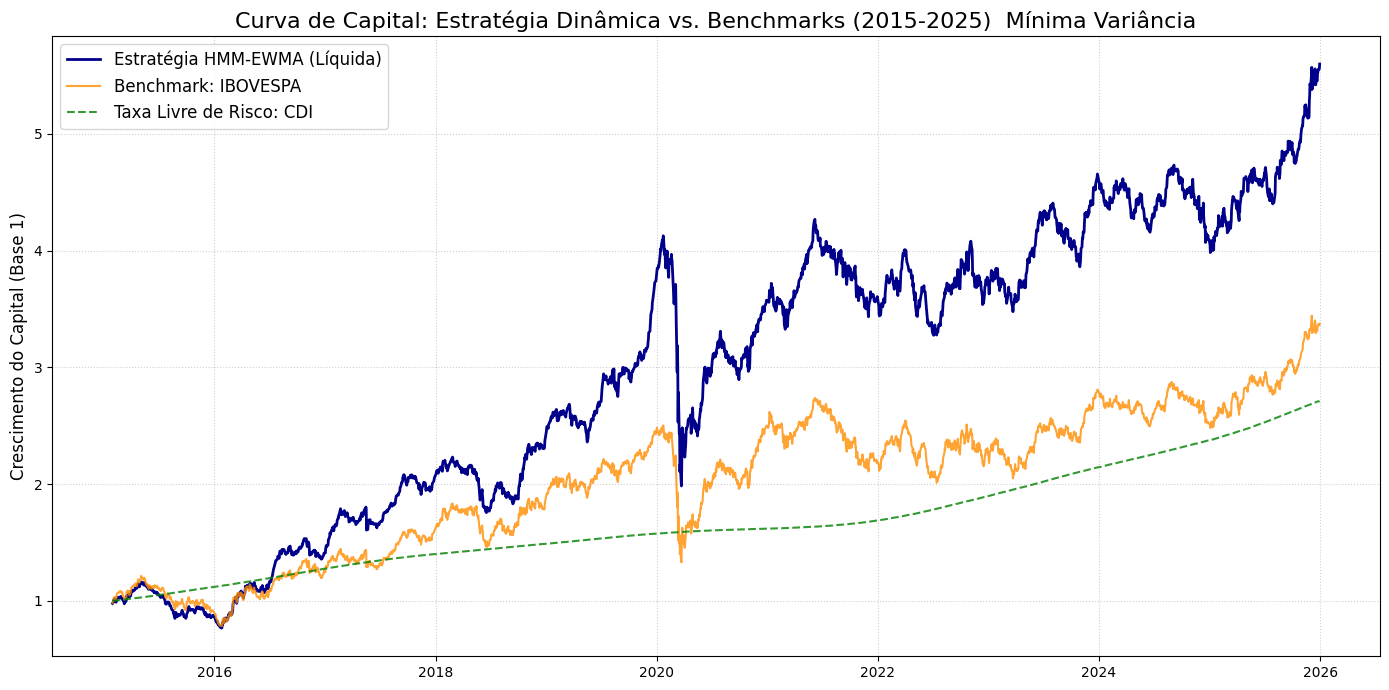


 🏆 TABELA DE MÉTRICAS FINAIS (KPIs) - Mínima Variância 
Período de Análise:    2015-01-30 a 2025-12-30
--------------------------------------------------
Métrica                   | Estratégia HMM | IBOVESPA
--------------------------------------------------
Retorno Total Acumulado   |    459.81% |   237.35%
Retorno Anual (CAGR)      |     17.38% |    11.98%
CDI Anualizado (Risk-Free) |      9.73% |     9.73%
--------------------------------------------------
Volatilidade Anualizada   |     21.02% |    23.31%
Índice de Sharpe          |      0.36  |     0.10
Maximum Drawdown          |    -51.91% |   -46.82%


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

def calcular_curva_capital_e_kpis(diretorio_dados):
    print("=== CÁLCULO DA CURVA DE CAPITAL E KPIs (Mínima Variância) ===")
    
    historico_pesos = pd.read_csv(os.path.join(diretorio_dados, "historico_alocacao_HMM_EWMA_minima_variancia.csv"), index_col=0, parse_dates=True)
    df_retornos = pd.read_csv(os.path.join(diretorio_dados, "matriz_retornos_simples_v2.csv"), index_col='Data', parse_dates=True)
    historico_turnover = pd.read_csv(os.path.join(diretorio_dados, "historico_turnover_minima_variancia.csv"), index_col=0, parse_dates=True)
    historico_turnover.columns = ['Turnover']
    
    # Carregar CDI Externo
    caminho_cdi = os.path.join(diretorio_dados, "CDI_2010_2026.xlsx")
    df_cdi = pd.read_excel(caminho_cdi)
    df_cdi = df_cdi.rename(columns={'Date': 'Data', 'valor': 'CDI'}).set_index('Data')
    df_cdi.index = pd.to_datetime(df_cdi.index)
    
    data_inicio = historico_pesos.index[0]
    df_retornos = df_retornos.loc[data_inicio:]
    
    pesos_diarios = historico_pesos.reindex(df_retornos.index).ffill().bfill() 
    
    retornos_ativos = df_retornos[historico_pesos.columns]
    retorno_carteira_bruto = (retornos_ativos * pesos_diarios).sum(axis=1)
    
    custos_diarios = pd.Series(0.0, index=retorno_carteira_bruto.index)
    custos_diarios.loc[historico_turnover.index] = historico_turnover['Turnover'] * 0.005
    retorno_carteira_liquido = retorno_carteira_bruto - custos_diarios
    
    # Alinhamento CDI sem necessidade de "limpeza de anomalia" (já está limpo)
    cdi_alinhado = df_cdi['CDI'].reindex(df_retornos.index).ffill()
    
    curva_estrategia = (1 + retorno_carteira_liquido).cumprod()
    curva_ibov = (1 + df_retornos['IBOV']).cumprod()
    curva_cdi = (1 + cdi_alinhado).cumprod()
    
    anos = len(retorno_carteira_liquido) / 252
    rf_anualizado = (curva_cdi.iloc[-1])**(1/anos) - 1
    
    cagr_est = (curva_estrategia.iloc[-1])**(1/anos) - 1
    cagr_ibov = (curva_ibov.iloc[-1])**(1/anos) - 1
    
    vol_est = retorno_carteira_liquido.std() * np.sqrt(252)
    vol_ibov = df_retornos['IBOV'].std() * np.sqrt(252)
    
    sharpe_est = (cagr_est - rf_anualizado) / vol_est
    sharpe_ibov = (cagr_ibov - rf_anualizado) / vol_ibov
    
    mdd_est = ((curva_estrategia / curva_estrategia.cummax()) - 1).min()
    mdd_ibov = ((curva_ibov / curva_ibov.cummax()) - 1).min()
    
    plt.figure(figsize=(14, 7))
    plt.plot(curva_estrategia, label='Estratégia HMM-EWMA (Líquida)', color='darkblue', linewidth=2)
    plt.plot(curva_ibov, label='Benchmark: IBOVESPA', color='darkorange', linewidth=1.5, alpha=0.8)
    plt.plot(curva_cdi, label='Taxa Livre de Risco: CDI', color='green', linewidth=1.5, linestyle='--', alpha=0.8)
    
    plt.title('Curva de Capital: Estratégia Dinâmica vs. Benchmarks (2015-2025)  Mínima Variância', fontsize=16)
    plt.ylabel('Crescimento do Capital (Base 1)', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper left', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(diretorio_dados, "curva_capital_kpis_minima_variancia.png"), dpi=300)
    plt.show()
    
    print("\n" + "="*50)
    print(" 🏆 TABELA DE MÉTRICAS FINAIS (KPIs) - Mínima Variância ")
    print("="*50)
    print(f"Período de Análise:    {data_inicio.date()} a {curva_estrategia.index[-1].date()}")
    print("-" * 50)
    print(f"{'Métrica':<25} | {'Estratégia HMM':<10} | {'IBOVESPA'}")
    print("-" * 50)
    print(f"{'Retorno Total Acumulado':<25} | {(curva_estrategia.iloc[-1]-1)*100:>9.2f}% | {(curva_ibov.iloc[-1]-1)*100:>8.2f}%")
    print(f"{'Retorno Anual (CAGR)':<25} | {cagr_est*100:>9.2f}% | {cagr_ibov*100:>8.2f}%")
    print(f"{'CDI Anualizado (Risk-Free)':<25} | {rf_anualizado*100:>9.2f}% | {rf_anualizado*100:>8.2f}%")
    print("-" * 50)
    print(f"{'Volatilidade Anualizada':<25} | {vol_est*100:>9.2f}% | {vol_ibov*100:>8.2f}%")
    print(f"{'Índice de Sharpe':<25} | {sharpe_est:>9.2f}  | {sharpe_ibov:>8.2f}")
    print(f"{'Maximum Drawdown':<25} | {mdd_est*100:>9.2f}% | {mdd_ibov*100:>8.2f}%")
    print("="*50)

pasta_dados = r"C:\VSCodeWorkspace\TCC_Escrito\data"
calcular_curva_capital_e_kpis(pasta_dados)